# Exploratory Data Analysis (EDA)

This section analyzes sales, profitability, customer behavior, product performance, and delivery performance to identify meaningful business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Engineered/Featured_Engineering.csv")

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Id,...,Delivery Performance,Profit Margin (%),Sales Bucket,Shipping Efficiency (%),Customer Lifetime Revenue,Customer Average Order Value,Order Size,Discount Category,Loss Order,Order Type
0,DEBIT,3,4,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,...,On Time,28.999999,Medium,133.333333,327.75,327.75,Single,Low,No,International
1,TRANSFER,5,4,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,...,Delayed,-80.000001,Medium,80.000000,327.75,327.75,Single,Low,Yes,International
2,CASH,4,4,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,...,On Time,-80.000001,Medium,100.000000,327.75,327.75,Single,Low,Yes,International
3,DEBIT,3,4,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,19490,...,On Time,8.000000,Medium,133.333333,327.75,327.75,Single,Low,No,International
4,PAYMENT,2,4,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,19489,...,On Time,44.999999,Medium,200.000000,327.75,327.75,Single,Low,No,International


In [4]:
df.shape

(180519, 60)

In [5]:
df.dtypes

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Id                        int64
Customer Segment                  object
Customer State                    object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market                            object
Order City                        object
Order Country                     object
Order Customer Id                  int64
order date (DateOrders)           object
Order Id                           int64
Order Item Cardprod Id             int64
Order Item Disco

In [6]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Id',
 'Customer Segment',
 'Customer State',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Card Id',
 'Product Category Id',
 'Product Name',
 'Product Price',
 'Product Status',
 'shipping date (DateOrders)',
 'Shipping Mode',
 'Order Year',
 'Order Month',
 'Order Month Name',
 'Order Quarter',
 'Order Weekday',
 'Weekend Order',
 'Shipping Delay',
 'De

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180519.0,35920.541998,37542.423343,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933
Longitude,180519.0,-84.915675,21.433241,-158.025986,-98.446312,-76.847908,-66.370583,115.263077
Order Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000


In [8]:
df.isna().sum().sort_values(ascending=False)

Shipping Efficiency (%)          5080
Type                                0
Order Month                         0
Order Profit Per Order              0
Order Region                        0
Order State                         0
Order Status                        0
Product Card Id                     0
Product Category Id                 0
Product Name                        0
Product Price                       0
Product Status                      0
shipping date (DateOrders)          0
Shipping Mode                       0
Order Year                          0
Order Month Name                    0
Days for shipping (real)            0
Order Quarter                       0
Order Weekday                       0
Weekend Order                       0
Shipping Delay                      0
Delivery Performance                0
Profit Margin (%)                   0
Sales Bucket                        0
Customer Lifetime Revenue           0
Customer Average Order Value        0
Order Size  

# 1. Supply Chain & Sales Analysis

In [10]:
gross_revenue = df["Sales"].sum()
net_revenue = df["Order Item Total"].sum()

print("Gross Revenue:", gross_revenue)
print("Net Revenue:", net_revenue)

Gross Revenue: 36784735.01337984
Net Revenue: 33054402.380216613


In [11]:
total_profit = df["Order Profit Per Order"].sum()

print("Total Profit:", total_profit)

Total Profit: 3966902.974050357


In [12]:
total_orders = df["Order Id"].nunique()

print("Total Orders:", total_orders)

Total Orders: 65752


In [13]:
total_customers = df["Customer Id"].nunique()

print("Total Customers:", total_customers)


Total Customers: 20652


In [14]:
total_quantity = df["Order Item Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 384079


In [15]:
average_order_value = net_revenue / total_orders

print("Average Order Value:", average_order_value)

Average Order Value: 502.71326165313013


In [16]:
average_delivery_delay = df["Shipping Delay"].mean()

print("Average Delivery Delay:", average_delivery_delay)

Average Delivery Delay: 0.5658074773292562


In [17]:
df["Delivery Performance"].value_counts()

Delivery Performance
Delayed    103400
On Time     77119
Name: count, dtype: int64

In [18]:
late_delivery_rate = (
    (df["Delivery Performance"] == "Delayed").sum()
    / len(df)
) * 100

print("Late Delivery Rate:", late_delivery_rate, "%")

Late Delivery Rate: 57.279289160697765 %


In [19]:
overall_profit_margin = (total_profit / net_revenue) * 100

print("Overall Profit Margin:", overall_profit_margin, "%")

Overall Profit Margin: 12.00113355074478 %



### Key Findings

- Gross Revenue: **$36.78M**
- Net Revenue: **$33.05M**
- Total Profit: **$3.97M**
- Total Orders: **65,752**
- Total Customers: **20,652**
- Total Quantity Sold: **384,079**
- Average Order Value: **$502.71**
- Late Delivery Rate: **57.28%**
- Overall Profit Margin: **12.00%**

### Conclusion

The business generated approximately **$33.05M in net revenue** and **$3.97M in total profit** across 65,752 orders. The overall profit margin was approximately **12%**, while the late delivery rate of **57.28%** indicates that delivery performance is an important operational area requiring attention.
The business demonstrates healthy financial performance with strong revenue generation and an overall profit margin of 12%. However, the 57.28% late-delivery rate indicates a significant operational weakness. Management should focus on improving delivery reliability while maintaining the current level of profitability.

# 2. Revenue Trend Analysis

In [20]:
monthly_revenue = (
    df.groupby(["Order Year", "Order Month"])["Order Item Total"]
      .sum()
      .reset_index()
)

monthly_revenue

,Order Year,Order Month,Order Item Total
0,2015,1,9.453822e+05
1,2015,2,8.330124e+05
2,2015,3,9.440501e+05
3,2015,4,9.120044e+05
4,2015,5,9.439398e+05
5,2015,6,9.202421e+05
6,2015,7,9.329368e+05
7,2015,8,9.251929e+05
8,2015,9,9.145224e+05
9,2015,10,9.431311e+05


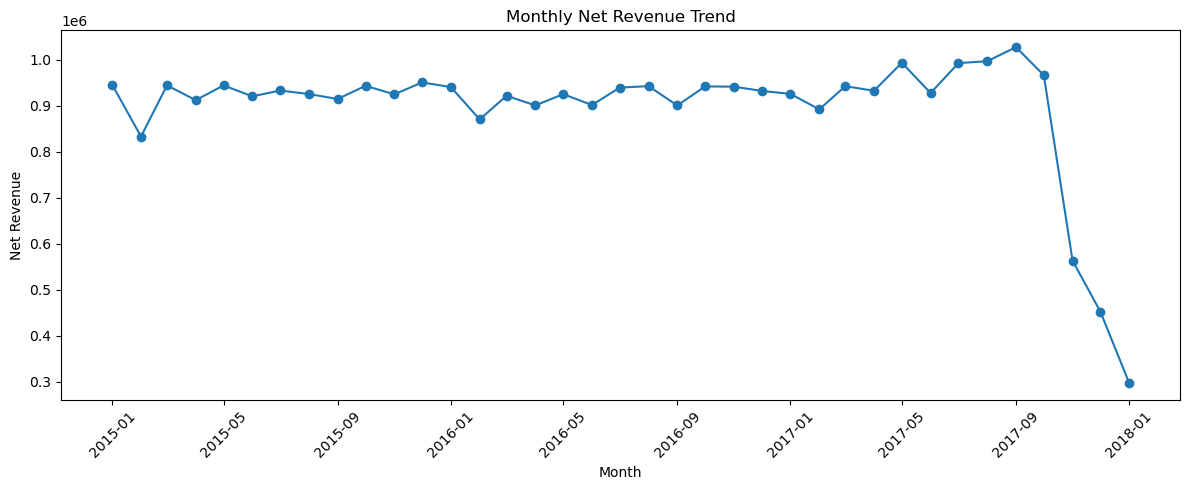

In [21]:
monthly_revenue["Period"] = (
    monthly_revenue["Order Year"].astype(str)
    + "-"
    + monthly_revenue["Order Month"].astype(str).str.zfill(2)
)

monthly_revenue["Period"] = pd.to_datetime(monthly_revenue["Period"])

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["Period"],
    monthly_revenue["Order Item Total"],
    marker="o"
)

plt.title("Monthly Net Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [22]:
df["order date (DateOrders)"].min(), df["order date (DateOrders)"].max()

('2015-01-01 00:00:00', '2018-01-31 23:38:00')

In [23]:
monthly_orders = (
    df.groupby(["Order Year", "Order Month"])["Order Id"]
      .nunique()
      .reset_index(name="Total Orders")
)

monthly_orders

,Order Year,Order Month,Total Orders
0,2015,1,1787
1,2015,2,1585
2,2015,3,1781
3,2015,4,1710
4,2015,5,1776
5,2015,6,1725
6,2015,7,1763
7,2015,8,1762
8,2015,9,1706
9,2015,10,1775


In [24]:
monthly_revenue_per_order = monthly_revenue.merge(
    monthly_orders,
    on=["Order Year", "Order Month"]
)

monthly_revenue_per_order["Revenue per Order"] = (
    monthly_revenue_per_order["Order Item Total"]
    / monthly_revenue_per_order["Total Orders"]
)

monthly_revenue_per_order

,Order Year,Order Month,Order Item Total,Period,Total Orders,Revenue per Order
0,2015,1,9.453822e+05,2015-01-01,1787,529.033106
1,2015,2,8.330124e+05,2015-02-01,1585,525.559892
2,2015,3,9.440501e+05,2015-03-01,1781,530.067440
3,2015,4,9.120044e+05,2015-04-01,1710,533.335907
4,2015,5,9.439398e+05,2015-05-01,1776,531.497618
5,2015,6,9.202421e+05,2015-06-01,1725,533.473658
6,2015,7,9.329368e+05,2015-07-01,1763,529.175718
7,2015,8,9.251929e+05,2015-08-01,1762,525.081084
8,2015,9,9.145224e+05,2015-09-01,1706,536.062351
9,2015,10,9.431311e+05,2015-10-01,1775,531.341465


In [25]:
monthly_quantity = (
    df.groupby(["Order Year", "Order Month"])["Order Item Quantity"]
      .sum()
      .reset_index(name="Total Quantity")
)

monthly_quantity = monthly_quantity.merge(
    monthly_orders,
    on=["Order Year", "Order Month"]
)

monthly_quantity["Quantity per Order"] = (
    monthly_quantity["Total Quantity"]
    / monthly_quantity["Total Orders"]
)

monthly_quantity

,Order Year,Order Month,Total Quantity,Total Orders,Quantity per Order
0,2015,1,11854,1787,6.633464
1,2015,2,10438,1585,6.585489
2,2015,3,12062,1781,6.772600
3,2015,4,11287,1710,6.600585
4,2015,5,11902,1776,6.701577
5,2015,6,11203,1725,6.494493
6,2015,7,11800,1763,6.693137
7,2015,8,11612,1762,6.590238
8,2015,9,11366,1706,6.662368
9,2015,10,11703,1775,6.593239


In [26]:
quantity_by_period = pd.crosstab(
    [df["Order Year"], df["Order Month"]],
    df["Order Item Quantity"]
)

quantity_by_period

Order Item Quantity        1    2    3    4    5
Order Year Order Month                          
2015       1            2714  669  623  647  669
           2            2451  555  595  548  580
           3            2664  678  680  698  642
           4            2680  577  640  612  617
           5            2711  680  671  657  638
           6            2670  647  627  592  598
           7            2685  683  650  606  675
           8            2725  644  649  623  632
           9            2667  604  628  598  643
           10           2756  631  622  646  647
           11           2745  641  589  631  629
           12           2796  643  662  628  642
2016       1            2811  641  603  615  647
           2            2552  570  597  593  582
           3            2732  633  630  614  601
           4            2644  615  624  608  606
           5            2765  652  634  623  628
           6            2653  616  607  588  590
           7            2778  623  620  652  632
           8            2817  613  614  652  638
           9            2701  642  580  626  611
           10           2796  659  619  655  669
           11           2752  574  594  639  651
           12           2697  615  648  642  667
2017       1            2639  662  638  662  616
           2            2477  573  618  597  641
           3            2815  630  627  655  620
           4            2829  592  601  577  613
           5            3028  583  557  577  572
           6            2866  493  539  540  513
           7            3002  558  611  595  552
           8            3030  509  600  583  583
           9            3024  586  528  533  518
           10           2160   24   25   23   23
           11           2055    0    0    0    0
           12           2124    0    0    0    0
2018       1            2123    0    0    0    0

In [27]:
monthly_item_value = (
    df.groupby(["Order Year", "Order Month"])["Order Item Total"]
      .mean()
      .reset_index(name="Average Item Value")
)

monthly_item_value

,Order Year,Order Month,Average Item Value
0,2015,1,177.636633
1,2015,2,176.149805
2,2015,3,176.063057
3,2015,4,177.917363
4,2015,5,176.206789
5,2015,6,179.244655
6,2015,7,176.059028
7,2015,8,175.458538
8,2015,9,177.922640
9,2015,10,177.882139


In [28]:
monthly_product_price = (
    df.groupby(["Order Year", "Order Month"])["Product Price"]
      .mean()
      .reset_index(name="Average Product Price")
)

monthly_product_price

,Order Year,Order Month,Average Product Price
0,2015,1,130.765932
1,2015,2,130.525438
2,2015,3,128.436215
3,2015,4,133.013230
4,2015,5,128.664859
5,2015,6,133.852037
6,2015,7,129.466004
7,2015,8,129.918120
8,2015,9,131.864268
9,2015,10,131.599924


In [29]:
monthly_discount = (
    df.groupby(["Order Year", "Order Month"])["Order Item Discount Rate"]
      .mean()
      .reset_index(name="Average Discount Rate")
)

monthly_discount

,Order Year,Order Month,Average Discount Rate
0,2015,1,0.101148
1,2015,2,0.101622
2,2015,3,0.101848
3,2015,4,0.101857
4,2015,5,0.101208
5,2015,6,0.101461
6,2015,7,0.101530
7,2015,8,0.102145
8,2015,9,0.102416
9,2015,10,0.101000


In [30]:
order_item_counts = (
    df.groupby("Order Id")["Order Item Id"]
      .nunique()
)

order_item_counts.describe()

count    65752.000000
mean         2.745453
std          1.478363
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Order Item Id, dtype: float64

In [31]:
monthly_items_per_order = (
    df.groupby(["Order Year", "Order Month"])
      .agg(
          Total_Items=("Order Item Id", "nunique"),
          Total_Orders=("Order Id", "nunique")
      )
      .reset_index()
)

monthly_items_per_order["Items per Order"] = (
    monthly_items_per_order["Total_Items"]
    / monthly_items_per_order["Total_Orders"]
)

monthly_items_per_order

,Order Year,Order Month,Total_Items,Total_Orders,Items per Order
0,2015,1,5322,1787,2.978176
1,2015,2,4729,1585,2.983596
2,2015,3,5362,1781,3.010668
3,2015,4,5126,1710,2.997661
4,2015,5,5357,1776,3.016329
5,2015,6,5134,1725,2.976232
6,2015,7,5299,1763,3.005672
7,2015,8,5273,1762,2.992622
8,2015,9,5140,1706,3.012896
9,2015,10,5302,1775,2.987042


In [32]:
monthly_products = (
    df.groupby(["Order Year", "Order Month"])["Product Card Id"]
      .nunique()
      .reset_index(name="Unique Products")
)

monthly_products

,Order Year,Order Month,Unique Products
0,2015,1,54
1,2015,2,54
2,2015,3,54
3,2015,4,54
4,2015,5,54
5,2015,6,54
6,2015,7,54
7,2015,8,54
8,2015,9,54
9,2015,10,54


In [33]:
product_period = (
    df.groupby(["Order Year", "Order Month"])["Product Name"]
      .nunique()
      .reset_index(name="Unique Product Names")
)

product_period

,Order Year,Order Month,Unique Product Names
0,2015,1,54
1,2015,2,54
2,2015,3,54
3,2015,4,54
4,2015,5,54
5,2015,6,54
6,2015,7,54
7,2015,8,54
8,2015,9,54
9,2015,10,54




### Key Findings

- Revenue remained relatively stable during **2015 and 2016**.
- Revenue became stronger during most of **2017**.
- Monthly revenue reached approximately **$1.03M in September 2017**.
- Revenue then declined sharply, reaching approximately **$0.30M in January 2018**.

### Important Observation

The late-period revenue decline coincided with a major structural change in the dataset:

- Unique products decreased from **53 in September 2017** to **20 in October** and **8 in November**.
- Average items per order decreased from approximately **3 to 1**.
- Order-item quantities also shifted almost entirely to **1**.

### Conclusion

Revenue showed strong performance through most of 2017 before declining sharply in the final months. Since this decline coincides with a major change in product coverage and order composition, the underlying data structure should be investigated before making strategic decisions.

Revenue was relatively stable during 2015 and 2016 and improved during most of 2017, reaching a peak in September 2017. After that, revenue declined significantly. However, I noticed that this decline happened at the same time as a major change in the dataset structure. The number of unique products and the number of items per order dropped significantly. So I would not directly conclude that the business performance deteriorated. I would first investigate whether this structural change in the data or product mix explains the decline.

# 3. Profitability Analysis

In [34]:
yearly_profit = (
    df.groupby("Order Year")["Order Profit Per Order"]
      .sum()
      .reset_index(name="Total Profit")
)

yearly_profit

,Order Year,Total Profit
0,2015,1.318857e+06
1,2016,1.310119e+06
2,2017,1.304085e+06
3,2018,3.384189e+04


In [35]:
yearly_profit_margin = (
    df.groupby("Order Year")
      .agg(
          Total_Profit=("Order Profit Per Order", "sum"),
          Net_Revenue=("Order Item Total", "sum")
      )
      .reset_index()
)

yearly_profit_margin["Profit Margin (%)"] = (
    yearly_profit_margin["Total_Profit"]
    / yearly_profit_margin["Net_Revenue"]
) * 100

yearly_profit_margin

,Order Year,Total_Profit,Net_Revenue,Profit Margin (%)
0,2015,1.318857e+06,1.108954e+07,11.892797
1,2016,1.310119e+06,1.105600e+07,11.849850
2,2017,1.304085e+06,1.061091e+07,12.290040
3,2018,3.384189e+04,2.979521e+05,11.358166


In [36]:
category_profit = (
    df.groupby("Category Name")["Order Profit Per Order"]
      .sum()
      .sort_values(ascending=False)
      .reset_index(name="Total Profit")
)

category_profit

,Category Name,Total Profit
0,Fishing,756220.767190
1,Cleats,494636.919791
2,Camping & Hiking,427455.568106
3,Cardio Equipment,383011.098485
4,Women's Apparel,350421.029567
5,Water Sports,325146.960038
6,Indoor/Outdoor Games,318451.430554
7,Men's Footwear,311902.820214
8,Shop By Sport,129813.960315
9,Computers,69656.810171


In [37]:
category_revenue = (
    df.groupby("Category Name")["Order Item Total"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="Net Revenue")
)

category_revenue

,Category Name,Net Revenue
0,Fishing,6.226935e+06
1,Cleats,3.982857e+06
2,Camping & Hiking,3.700784e+06
3,Cardio Equipment,3.320251e+06
4,Women's Apparel,2.828708e+06
5,Water Sports,2.798044e+06
6,Men's Footwear,2.598494e+06
7,Indoor/Outdoor Games,2.596454e+06
8,Shop By Sport,1.177186e+06
9,Computers,5.953950e+05


In [39]:
category_performance = (
    df.groupby("Category Name")
      .agg(
          Net_Revenue=("Order Item Total", "sum"),
          Total_Profit=("Order Profit Per Order", "sum")
      )
      .reset_index()
)

category_performance["Profit Margin (%)"] = (
    category_performance["Total_Profit"]
    / category_performance["Net_Revenue"]
) * 100

category_performance.sort_values(
    "Net_Revenue",
    ascending=False
).head(10)

,Category Name,Net_Revenue,Total_Profit,Profit Margin (%)
18,Fishing,6.226935e+06,756220.767190,12.144349
12,Cleats,3.982857e+06,494636.919791,12.419150
9,Camping & Hiking,3.700784e+06,427455.568106,11.550407
10,Cardio Equipment,3.320251e+06,383011.098485,11.535608
47,Women's Apparel,2.828708e+06,350421.029567,12.388022
46,Water Sports,2.798044e+06,325146.960038,11.620508
34,Men's Footwear,2.598494e+06,311902.820214,12.003213
30,Indoor/Outdoor Games,2.596454e+06,318451.430554,12.264859
38,Shop By Sport,1.177186e+06,129813.960315,11.027484
13,Computers,5.953950e+05,69656.810171,11.699260




### Key Findings

Annual profit remained relatively stable from 2015 to 2017:

- **2015:** $1.319M
- **2016:** $1.310M
- **2017:** $1.304M

The profit margin was:

- **2015:** 11.89%
- **2016:** 11.85%
- **2017:** 12.29%

### Category Profitability

The highest total-profit categories were:

1. **Fishing:** $756K
2. **Cleats:** $495K
3. **Camping & Hiking:** $427K
4. **Cardio Equipment:** $383K
5. **Women's Apparel:** $350K

Fishing generated the highest total profit, while **Cleats had the highest profit margin among the top 10 revenue-generating categories at approximately 12.42%**.

### Conclusion

Annual profit remained relatively stable at approximately **$1.3M from 2015 to 2017**, while the profit margin improved slightly in 2017. Fishing was the strongest category by total profit, while Cleats showed slightly better profitability efficiency among the top revenue-generating categories.
Profit remained relatively stable between 2015 and 2017, while profit margin improved slightly. The business should prioritize categories that combine strong revenue with healthy margins. This can help improve profitability without relying solely on increasing sales volume.

# 4. Delivery Performance Analysis

In [41]:
shipping_mode_performance = (
    df.groupby("Shipping Mode")
      .agg(
          Total_Orders=("Order Id", "nunique"),
          Delayed_Orders=(
              "Order Id",
              lambda x: x[df.loc[x.index, "Delivery Performance"] == "Delayed"].nunique()
          )
      )
      .reset_index()
)

shipping_mode_performance["Late Delivery Rate (%)"] = (
    shipping_mode_performance["Delayed_Orders"]
    / shipping_mode_performance["Total_Orders"]
) * 100

shipping_mode_performance

,Shipping Mode,Total_Orders,Delayed_Orders,Late Delivery Rate (%)
0,First Class,10079,10079,100.000000
1,Same Day,3571,1727,48.361803
2,Second Class,12778,10213,79.926436
3,Standard Class,39324,15679,39.871325


In [42]:
pd.crosstab(
    df["Shipping Mode"],
    df["Delivery Performance"]
)

Delivery Performance,Delayed,On Time
Shipping Mode,,
First Class,27814,0
Same Day,4657,5080
Second Class,28078,7138
Standard Class,42851,64901


In [43]:
df["Shipping Delay"].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Shipping Delay, dtype: float64

### Key Findings

| Shipping Mode | Late Delivery Rate |
|---|---:|
| First Class | 100.00% |
| Second Class | 79.93% |
| Same Day | 48.36% |
| Standard Class | 39.87% |

- **Overall Late Delivery Rate:** 57.28%
- **Average Shipping Delay:** 0.57 days
- **Median Shipping Delay:** 1 day
- Shipping delay ranged from **2 days early to 4 days late**.

### Conclusion

Delivery performance is a major area requiring attention, with more than half of deliveries classified as delayed. First Class and Second Class show particularly high delay rates. Management should investigate the operational factors behind these delays and evaluate opportunities to improve fulfillment reliability.

# 5. Customer Analysis

In [44]:
customer_segment = (
    df.groupby("Customer Segment")
      .agg(
          Revenue=("Order Item Total", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Orders=("Order Id", "nunique")
      )
      .reset_index()
)

customer_segment

,Customer Segment,Revenue,Profit,Orders
0,Consumer,1.716428e+07,2.073488e+06,34119
1,Corporate,1.003065e+07,1.202575e+06,19856
2,Home Office,5.859474e+06,6.908403e+05,11777


In [45]:
top_customers = (
    df.groupby("Customer Id")["Customer Lifetime Revenue"]
      .max()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer Id
791     10524.170178
9371     9299.030207
8766     9296.140186
1657     9223.710152
2641     9130.920224
1288     9019.110199
3710     9019.100208
4249     8918.850134
5654     8904.950211
5624     8761.980183
Name: Customer Lifetime Revenue, dtype: float64

### Customer Segment Performance

| Customer Segment | Revenue | Profit | Orders |
|---|---:|---:|---:|
| Consumer | $17.16M | $2.07M | 34,119 |
| Corporate | $10.03M | $1.20M | 19,856 |
| Home Office | $5.86M | $0.69M | 11,777 |

### Key Finding

The **Consumer segment** is the largest customer segment, generating approximately **$17.16M in revenue** and **$2.07M in profit**.

The highest customer lifetime revenue observed was approximately **$10.52K**, generated by Customer 791.

### Conclusion

The Consumer segment is the largest contributor to both revenue and profit. The business should prioritize retaining these customers while exploring opportunities to increase engagement within the Corporate and Home Office segments. High-value customers should also be considered for targeted retention strategies.

# 6. Product & Category Analysis

In [46]:
top_products = (
    df.groupby("Product Name")["Order Item Total"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Field & Stream Sportsman 16 Gun Fire Safe        6.226935e+06
Perfect Fitness Perfect Rip Deck                 3.973180e+06
Diamondback Women's Serene Classic Comfort Bi    3.700784e+06
Nike Men's Free 5.0+ Running Shoe                3.295693e+06
Nike Men's Dri-FIT Victory Golf Polo             2.828708e+06
Pelican Sunstream 100 Kayak                      2.785518e+06
Nike Men's CJ Elite 2 TD Football Cleat          2.598494e+06
O'Brien Men's Neoprene Life Vest                 2.596454e+06
Under Armour Girls' Toddler Spine Surge Runni    1.140771e+06
Dell Laptop                                      5.953950e+05
Name: Order Item Total, dtype: float64


### Key Findings

Fishing was the highest revenue-generating category with approximately **$6.23M** in net revenue and **$756K** in total profit.

Other major revenue-generating categories included:

- Cleats: **$3.98M**
- Camping & Hiking: **$3.70M**
- Cardio Equipment: **$3.32M**
- Women's Apparel: **$2.83M**

### Top Revenue-Generating Products

1. **Field & Stream Sportsman 16 Gun Fire Safe** — $6.23M
2. **Perfect Fitness Perfect Rip Deck** — $3.97M
3. **Diamondback Women's Serene Classic Comfort Bike** — $3.70M
4. **Nike Men's Free 5.0+ Running Shoe** — $3.30M
5. **Nike Men's Dri-FIT Victory Golf Polo** — $2.83M

### Conclusion

A relatively small number of categories contribute a substantial share of revenue and profit, with Fishing being the strongest overall performer. The business should continue supporting high-performing categories while reviewing lower-margin categories for opportunities to improve profitability.